In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
#df = pd.read_csv("Downloads/garch_volatility (1).csv")
df = pd.read_csv("Final dataset with mac vari.csv")

In [3]:
df.columns

Index(['Date', 'USD_EUR_Ratio', 'Gold_Price', 'Index', 'volatility',
       'Newscore', 'Newsenti', 'garch_volatility'],
      dtype='object')

In [4]:
le = LabelEncoder()
df["News Sentiment"] = le.fit_transform(df["Newsenti"].astype(str))

In [5]:
df['vol_1'] = df['volatility'].shift(1)

In [6]:
X = df[["Newscore", "News Sentiment", "Index",'vol_1']]
y = df["volatility"]

In [7]:
 df = df.dropna()
X = X.loc[df.index]
y = y.loc[df.index]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
y_pred = model.predict(X_test)

In [11]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.05789579082710894
MAE: 0.0033292393790842166
RMSE: 0.00447607060240605


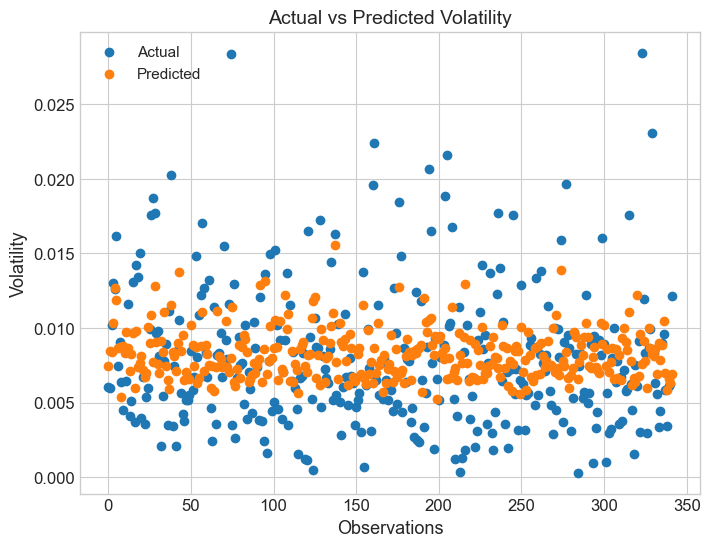

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure(figsize=(8,6))
# Actual values
plt.scatter(range(len(y_test)), y_test, label="Actual")
# Predicted values
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Observations")
plt.ylabel("Volatility")
plt.title("Actual vs Predicted Volatility")
plt.savefig("Actual vs Predicted Volatility.png", dpi=300)
plt.legend()
plt.show()

In [13]:
X = df[["Newscore", 'vol_1',"News Sentiment","Index"]]
y = df["garch_volatility"]

In [14]:
df = df.dropna()
X = X.loc[df.index]
y = y.loc[df.index]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.27536956662334877
MAE: 0.088243382336669
RMSE: 0.10736639681856454


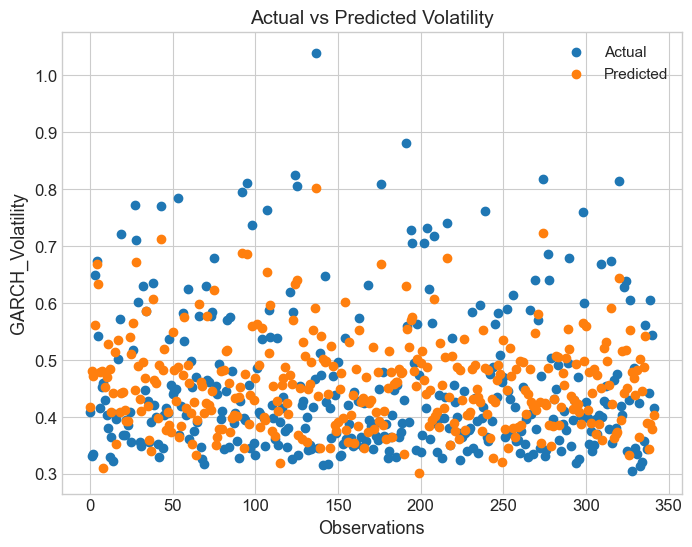

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure(figsize=(8,6))
# Actual values
plt.scatter(range(len(y_test)), y_test, label="Actual")
# Predicted values
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Observations")
plt.ylabel("GARCH_Volatility")
plt.title("Actual vs Predicted Volatility")
plt.savefig("Actual vs Predicted VolatilityGARCH.png", dpi=300)
plt.legend()
plt.show()

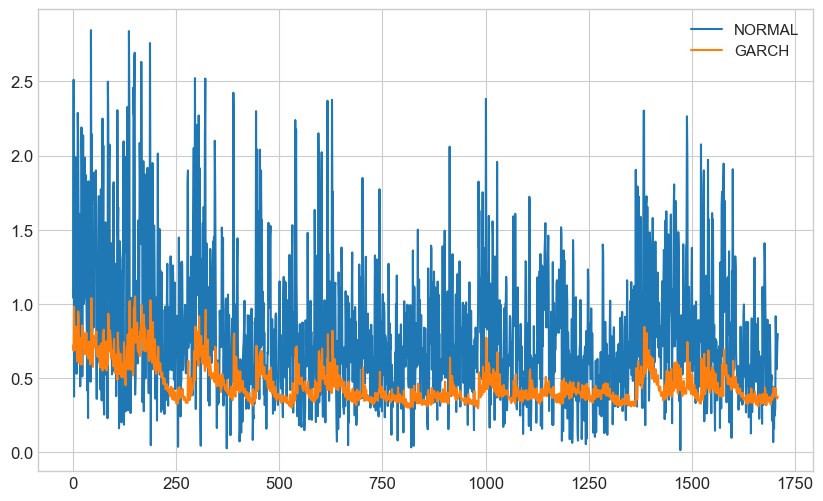

In [20]:
plt.plot(df['volatility']*100, label='NORMAL')
plt.plot(df['garch_volatility'], label='GARCH')
plt.savefig("Normal VS GARCH.png", dpi=300)
plt.legend()

In [21]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# Sort by time (VERY IMPORTANT)
df = df.sort_values(by='Date')
Y = df['volatility']
X = df.drop(columns=['volatility','Date','garch_volatility','Newsenti'])

In [22]:
n = len(df)

splits = [
    int(0.83 * n),   # ~10 months
    int(0.92 * n),   # ~11 months
    int(0.96 * n),   # ~11.5 months
    int(0.98 * n)    # ~11.75 months
]

In [23]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = LinearRegression()
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)
    
        # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)
    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)
    
    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })
    
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)

results_df = pd.DataFrame(results)


    Split 1
    Train Size: 1417
    Test Size: 291
    MSE: 0.0000
    MAE: 0.0034
    R2: 0.1128
    Directional Accuracy: 0.7801
    

    Split 2
    Train Size: 1571
    Test Size: 137
    MSE: 0.0000
    MAE: 0.0032
    R2: 0.0579
    Directional Accuracy: 0.7737
    

    Split 3
    Train Size: 1639
    Test Size: 69
    MSE: 0.0000
    MAE: 0.0032
    R2: -0.0203
    Directional Accuracy: 0.7391
    

    Split 4
    Train Size: 1673
    Test Size: 35
    MSE: 0.0000
    MAE: 0.0033
    R2: 0.0226
    Directional Accuracy: 0.7143
    


In [24]:
Y = df['garch_volatility']
X = df.drop(columns=[ 'Date','garch_volatility','Newsenti'])

In [25]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = LinearRegression()
    model.fit(X_train, Y_train)

    preds = model.predict(X_test)
    
        # --- Metrics ---
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)
    # --- Directional Accuracy ---
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)
    
    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })
    
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)

results_df = pd.DataFrame(results)


    Split 1
    Train Size: 1417
    Test Size: 291
    MSE: 0.0083
    MAE: 0.0698
    R2: 0.5377
    Directional Accuracy: 0.7973
    

    Split 2
    Train Size: 1571
    Test Size: 137
    MSE: 0.0078
    MAE: 0.0680
    R2: 0.5638
    Directional Accuracy: 0.8175
    

    Split 3
    Train Size: 1639
    Test Size: 69
    MSE: 0.0085
    MAE: 0.0692
    R2: 0.5749
    Directional Accuracy: 0.8116
    

    Split 4
    Train Size: 1673
    Test Size: 35
    MSE: 0.0097
    MAE: 0.0750
    R2: 0.5382
    Directional Accuracy: 0.8000
    


In [26]:
#df.to_csv("Datasets.csv")

In [27]:
results_df = pd.DataFrame(results)
print(results_df)

   Split  Train Size  Test Size       MSE       MAE        R2  \
0      1        1417        291  0.008330  0.069771  0.537713   
1      2        1571        137  0.007768  0.067958  0.563830   
2      3        1639         69  0.008521  0.069181  0.574866   
3      4        1673         35  0.009693  0.075048  0.538154   

   Directional Accuracy  
0              0.797251  
1              0.817518  
2              0.811594  
3              0.800000  
